# Shor's Algorithm for Factoring `N = 21`

## Goal

This notebook demonstrates the main workflow of **Shor's algorithm** using the toy RSA modulus:

`N = 21`

The goal is to recover the non-trivial factors:

`21 = 3 × 7`

This connects directly to the RSA notebook, where `n = 21` is used as the toy public RSA modulus.

## Why this matters

RSA security depends on the difficulty of factoring a large number `n = p × q`.

Shor's algorithm is the direct quantum threat to RSA because it turns factoring into an **order-finding** problem. A sufficiently powerful fault-tolerant quantum computer could use this idea to attack RSA-sized moduli.

## Main result

Using base:

`a = 2`

the order-finding step recovers:

`r = 6`

Then classical post-processing computes:

`gcd(2^(6/2) - 1, 21) = 7`

and:

`gcd(2^(6/2) + 1, 21) = 3`

Therefore, the algorithm recovers:

`21 = 3 × 7`

## Important limitation

This is a **toy-scale educational simulation**. It does not break real RSA.


## 0. Optional Setup

Run this cell only if Qiskit is not installed.

For GitHub, it is better to keep this cell clean and quiet so the notebook does not contain long installation logs.


In [ ]:
# Optional: uncomment if running in a fresh environment such as Google Colab.
# %pip install -q "qiskit>=2.1.0" "qiskit-aer>=0.17.0" "numpy" "pandas" "matplotlib" "pylatexenc"



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 1. Imports and Figure Folder

The `figures/` folder is used for images that can be included in the GitHub README.


In [17]:
from pathlib import Path
from fractions import Fraction
from math import gcd, pi

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit.circuit.library import UnitaryGate
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator


# If this notebook is inside a notebooks/ folder, save figures to ../figures.
# Otherwise, save figures to ./figures.
if Path.cwd().name == "notebooks":
    FIGURES_DIR = Path("../figures")
else:
    FIGURES_DIR = Path("figures")

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Figures will be saved to: {FIGURES_DIR.resolve()}")


Figures will be saved to: /Users/harrydo/Documents/CS480Q/quantum-rsa-post-quantum-crypto/figures


## 2. Shor Input Parameters

For this project, the number to factor is:

`N = 21`

This matches the toy RSA modulus from the RSA notebook.

We choose:

`a = 2`

The value `a` must satisfy:

`gcd(a, N) = 1`

If `gcd(a, N)` is not 1, then we have already found a factor without needing the quantum part.


In [18]:
N = 21
a = 2

print(f"N = {N}")
print(f"a = {a}")
print(f"gcd(a, N) = {gcd(a, N)}")

if gcd(a, N) != 1:
    print(f"Because gcd({a}, {N}) is not 1, this already gives a factor.")
else:
    print("Since gcd(a, N) = 1, we continue to order finding.")


N = 21
a = 2
gcd(a, N) = 1
Since gcd(a, N) = 1, we continue to order finding.


## 3. Classical Order Check

Shor's algorithm needs the **order** `r`.

The order is the smallest positive integer such that:

`a^r ≡ 1 mod N`

For this example, we are looking for:

`2^r ≡ 1 mod 21`

The quantum circuit is designed to estimate this order. Before building the quantum circuit, we check the expected answer classically so we can verify the simulation later.


In [19]:
def classical_order(a, N):
    """
    Return the smallest positive r such that a^r is congruent to 1 mod N.
    This is only used for verification in this educational notebook.
    """
    if gcd(a, N) != 1:
        return None

    value = 1

    for r in range(1, N):
        value = (value * a) % N

        if value == 1:
            return r

    return None


expected_r = classical_order(a, N)

power_rows = []
value = 1

for r in range(1, expected_r + 1):
    value = (value * a) % N
    power_rows.append({
        "r": r,
        f"{a}^r mod {N}": value
    })

df_order_check = pd.DataFrame(power_rows)

print(f"Expected order r = {expected_r}")
df_order_check


Expected order r = 6


,r,2^r mod 21
0,1,2
1,2,4
2,3,8
3,4,16
4,5,11
5,6,1


## 4. Helper Functions

This notebook uses three helper functions:

1. `required_qubits(N)`  
   Computes how many qubits are needed to represent numbers from `0` to `N - 1`.

2. `mod_mult_gate(b, N)`  
   Builds a modular multiplication gate:

   `|x⟩ → |b × x mod N⟩`

3. `inverse_qft(num_qubits)`  
   Builds the inverse Quantum Fourier Transform used in phase estimation.

For `N = 21`, we need 5 target qubits because:

`2^5 = 32`

This can represent values from `0` to `31`, which includes `0` to `20`.


In [20]:
def required_qubits(N):
    """
    Return the number of qubits needed to represent values from 0 to N - 1.
    """
    return (N - 1).bit_length()


def mod_mult_gate(b, N):
    """
    Build a modular multiplication gate for |x> -> |b*x mod N>.

    This implementation creates a permutation matrix. It is clear for a toy
    example, but it is not scalable for real RSA-sized numbers.
    """
    if gcd(b, N) != 1:
        raise ValueError(f"gcd({b}, {N}) must be 1.")

    num_target = required_qubits(N)
    dim = 2 ** num_target

    U = np.zeros((dim, dim), dtype=complex)

    # Map valid basis states |x> for x < N.
    for x in range(N):
        U[(b * x) % N, x] = 1

    # Leave unused states unchanged.
    # For N = 21, 5 qubits give 32 states, so states 21 to 31 are unused.
    for x in range(N, dim):
        U[x, x] = 1

    gate = UnitaryGate(U)
    gate.name = f"M_{b}_mod_{N}"

    return gate


def inverse_qft(num_qubits):
    """
    Construct the inverse Quantum Fourier Transform circuit.
    """
    qc = QuantumCircuit(num_qubits, name="IQFT")

    # Reverse qubit order.
    for qubit in range(num_qubits // 2):
        qc.swap(qubit, num_qubits - qubit - 1)

    # Apply inverse controlled phase rotations and Hadamards.
    for j in range(num_qubits):
        for m in range(j):
            qc.cp(-pi / (2 ** (j - m)), m, j)
        qc.h(j)

    return qc.to_gate()


## 5. Build the Shor Order-Finding Circuit

The circuit has two main registers:

| Register | Purpose |
|---|---|
| Control register | Stores phase information from modular exponentiation |
| Target register | Stores values involved in modular multiplication |

For `N = 21`:

- Target qubits = 5
- Control qubits = 10

The control register uses more qubits to estimate the phase with better precision.

The circuit performs three main steps:

1. Put the control register into superposition.
2. Apply controlled modular multiplication gates.
3. Apply inverse QFT and measure the control register.


In [21]:
num_target = required_qubits(N)
num_control = 2 * num_target

print(f"Number of target qubits = {num_target}")
print(f"Number of control qubits = {num_control}")

# b_k = a^(2^k) mod N
b_list = [pow(a, 2 ** k, N) for k in range(num_control)]
print(f"Controlled modular multiplication bases: {b_list}")

control = QuantumRegister(num_control, name="C")
target = QuantumRegister(num_target, name="T")
output = ClassicalRegister(num_control, name="out")

circuit = QuantumCircuit(control, target, output)

# Initialize target register to |1>.
circuit.x(target[0])

# Apply Hadamards and controlled modular multiplication gates.
for k, control_qubit in enumerate(control):
    circuit.h(control_qubit)

    b = b_list[k]

    # If b = 1, multiplication by 1 does not change the state.
    if b != 1:
        controlled_gate = mod_mult_gate(b, N).control()
        circuit.compose(
            controlled_gate,
            qubits=[control_qubit] + list(target),
            inplace=True
        )

# Apply inverse QFT to the control register.
circuit.append(inverse_qft(num_control), control)

# Measure the control register.
circuit.measure(control, output)

print(circuit)


Number of target qubits = 5
Number of control qubits = 10
Controlled modular multiplication bases: [2, 4, 16, 4, 16, 4, 16, 4, 16, 4]
        ┌───┐                                                             »
   C_0: ┤ H ├───────■─────────────────────────────────────────────────────»
        ├───┤       │                                                     »
   C_1: ┤ H ├───────┼──────────────■──────────────────────────────────────»
        ├───┤       │              │                                      »
   C_2: ┤ H ├───────┼──────────────┼──────────────■───────────────────────»
        ├───┤       │              │              │                       »
   C_3: ┤ H ├───────┼──────────────┼──────────────┼───────────────■───────»
        ├───┤       │              │              │               │       »
   C_4: ┤ H ├───────┼──────────────┼──────────────┼───────────────┼───────»
        ├───┤       │              │              │               │       »
   C_5: ┤ H ├───────┼─────────

## 6. Optional Circuit Figure

The full Shor circuit can be large, so this figure is optional. It is useful for the notebook, but it is usually too detailed for the README.

Recommended filename:

`figures/shor_order_finding_circuit.png`


In [22]:
SAVE_CIRCUIT_FIGURE = True

if SAVE_CIRCUIT_FIGURE:
    fig = circuit.draw(output="mpl", fold=120)
    fig.savefig(FIGURES_DIR / "shor_order_finding_circuit.png", bbox_inches="tight", dpi=200)
    fig


## 7. Run the Simulator

The simulator measures bitstrings from the control register.

These bitstrings are not the factors directly. They are used to estimate phases, and the phases are converted into candidate orders using continued fractions.

For this toy example, the useful order is:

`r = 6`


In [23]:
simulator = AerSimulator(seed_simulator=42)
shots = 4096

try:
    circuit_sim = transpile(circuit, simulator, optimization_level=0)

    sim_result = simulator.run(circuit_sim, shots=shots).result()
    sim_counts = sim_result.get_counts()

    print("Simulator completed successfully.")

except Exception as error:
    print("Simulator execution failed or was too expensive.")
    print("Error:", error)

    print("\nUsing ideal theoretical phase peaks for r = 6 as fallback.")

    def ideal_period_counts(r, num_control, shots):
        counts = {}
        base = shots // r
        remainder = shots % r

        for s in range(r):
            decimal = round((s / r) * (2 ** num_control)) % (2 ** num_control)
            bitstring = format(decimal, f"0{num_control}b")
            counts[bitstring] = counts.get(bitstring, 0) + base

        first_key = next(iter(counts))
        counts[first_key] += remainder

        return counts

    sim_counts = ideal_period_counts(expected_r, num_control, shots)

top_sim_counts = dict(
    sorted(sim_counts.items(), key=lambda item: item[1], reverse=True)[:12]
)

print("Top measurement outcomes:")
for bitstring, count in top_sim_counts.items():
    print(f"{bitstring}: {count}")


Simulator completed successfully.
Top measurement outcomes:
1000000000: 696
0000000000: 654
0010101011: 499
1010101011: 479
1101010101: 468
0101010101: 457
0101010110: 131
1010101010: 126
1101010110: 118
0010101010: 101
1101010100: 32
0101010100: 28


## 8. Measurement Histogram

This histogram shows the most frequent measured bitstrings from the simulator.

Recommended filename:

`figures/shor_measurement_histogram.png`

This is a good figure for the README because it shows the phase-estimation output that leads to recovering `r = 6`.


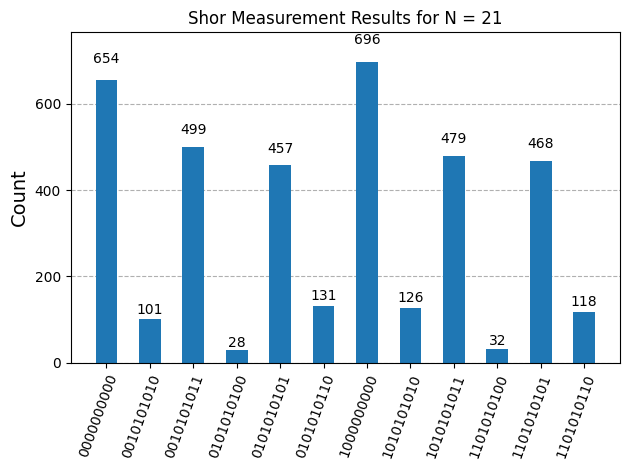

In [24]:
fig = plot_histogram(top_sim_counts, title="Shor Measurement Results for N = 21")
fig.savefig(FIGURES_DIR / "shor_measurement_histogram.png", bbox_inches="tight", dpi=200)
fig


## 9. Convert Bitstrings into Phases

Each measured bitstring is converted into a decimal value.

Then the phase is computed as:

`phase = measured_decimal / 2^num_control`

The phase is approximately:

`s / r`

where `r` is the order.


In [25]:
phase_rows = []
measured_phases = []

for bitstring, count in top_sim_counts.items():
    decimal = int(bitstring, 2)
    phase = decimal / (2 ** num_control)

    measured_phases.append(phase)

    phase_rows.append({
        "Bitstring": bitstring,
        "Count": count,
        "Decimal": decimal,
        "Phase": phase
    })

df_phases = pd.DataFrame(phase_rows)

df_phases


,Bitstring,Count,Decimal,Phase
0,1000000000,696,512,0.500000
1,0000000000,654,0,0.000000
2,0010101011,499,171,0.166992
3,1010101011,479,683,0.666992
4,1101010101,468,853,0.833008
5,0101010101,457,341,0.333008
6,0101010110,131,342,0.333984
7,1010101010,126,682,0.666016
8,1101010110,118,854,0.833984
9,0010101010,101,170,0.166016


## 10. Estimate the Order Using Continued Fractions

The measured phase is approximated as a fraction:

`phase ≈ s / r`

The denominator gives a candidate for `r`.

Sometimes the denominator is a divisor of the real order. For example:

`3/6 = 1/2`

So this notebook checks multiples of the denominator until it finds a value satisfying:

`a^r ≡ 1 mod N`


In [26]:
def estimate_order_from_phase(phase, a, N):
    """
    Estimate the order r from a measured phase.

    The denominator from continued fractions may be a divisor of the true order.
    This function checks multiples of the denominator until it finds a value r
    such that a^r is congruent to 1 mod N.
    """
    if phase == 0:
        return Fraction(0, 1), None

    frac = Fraction(phase).limit_denominator(N)
    denominator = frac.denominator

    for multiplier in range(1, N + 1):
        candidate_r = denominator * multiplier

        if pow(a, candidate_r, N) == 1:
            return frac, candidate_r

    return frac, denominator


order_rows = []

for phase in measured_phases:
    frac, recovered_r = estimate_order_from_phase(phase, a, N)

    order_rows.append({
        "Phase": phase,
        "Fraction": f"{frac.numerator}/{frac.denominator}",
        "Denominator": frac.denominator,
        "Recovered order r": recovered_r
    })

df_orders = pd.DataFrame(order_rows)

df_orders


,Phase,Fraction,Denominator,Recovered order r
0,0.500000,1/2,2,6.0
1,0.000000,0/1,1,NaN
2,0.166992,1/6,6,6.0
3,0.666992,2/3,3,6.0
4,0.833008,5/6,6,6.0
5,0.333008,1/3,3,6.0
6,0.333984,1/3,3,6.0
7,0.666016,2/3,3,6.0
8,0.833984,5/6,6,6.0
9,0.166016,1/6,6,6.0


## 11. Recover Factors from the Order

Once an even order `r` is found, Shor's classical post-processing uses:

`gcd(a^(r/2) - 1, N)`

and:

`gcd(a^(r/2) + 1, N)`

For this notebook:

`a = 2`

`r = 6`

`N = 21`

So:

`gcd(2^3 - 1, 21) = gcd(7, 21) = 7`

`gcd(2^3 + 1, 21) = gcd(9, 21) = 3`


In [27]:
shor_rows = []

for bitstring, count in top_sim_counts.items():
    decimal = int(bitstring, 2)
    phase = decimal / (2 ** num_control)

    frac, r_guess = estimate_order_from_phase(phase, a, N)

    factor_1 = None
    factor_2 = None
    recovered_factors = []
    success = False

    if r_guess is not None and r_guess % 2 == 0:
        x = pow(a, r_guess // 2, N)

        # If x = -1 mod N, this measurement does not produce useful factors.
        if x != N - 1:
            factor_1 = gcd(x - 1, N)
            factor_2 = gcd(x + 1, N)

            if factor_1 not in [1, N]:
                recovered_factors.append(factor_1)

            if factor_2 not in [1, N]:
                recovered_factors.append(factor_2)

            if recovered_factors:
                success = True

    shor_rows.append({
        "Bitstring": bitstring,
        "Count": count,
        "Decimal": decimal,
        "Phase": phase,
        "Fraction": f"{frac.numerator}/{frac.denominator}",
        "Recovered order r": r_guess,
        "gcd(a^(r/2)-1, N)": factor_1,
        "gcd(a^(r/2)+1, N)": factor_2,
        "Recovered factors": recovered_factors,
        "Successful factor?": success
    })

df_shor_results = pd.DataFrame(shor_rows)

df_shor_results


,Bitstring,Count,Decimal,Phase,Fraction,Recovered order r,"gcd(a^(r/2)-1, N)","gcd(a^(r/2)+1, N)",Recovered factors,Successful factor?
0,1000000000,696,512,0.500000,1/2,6.0,7.0,3.0,"[7, 3]",True
1,0000000000,654,0,0.000000,0/1,NaN,NaN,NaN,[],False
2,0010101011,499,171,0.166992,1/6,6.0,7.0,3.0,"[7, 3]",True
3,1010101011,479,683,0.666992,2/3,6.0,7.0,3.0,"[7, 3]",True
4,1101010101,468,853,0.833008,5/6,6.0,7.0,3.0,"[7, 3]",True
5,0101010101,457,341,0.333008,1/3,6.0,7.0,3.0,"[7, 3]",True
6,0101010110,131,342,0.333984,1/3,6.0,7.0,3.0,"[7, 3]",True
7,1010101010,126,682,0.666016,2/3,6.0,7.0,3.0,"[7, 3]",True
8,1101010110,118,854,0.833984,5/6,6.0,7.0,3.0,"[7, 3]",True
9,0010101010,101,170,0.166016,1/6,6.0,7.0,3.0,"[7, 3]",True


## 12. Successful Factor Recoveries

This table keeps only the rows where the post-processing recovered a non-trivial factor.


In [28]:
successful_rows = df_shor_results[
    df_shor_results["Successful factor?"] == True
].copy()

successful_rows


,Bitstring,Count,Decimal,Phase,Fraction,Recovered order r,"gcd(a^(r/2)-1, N)","gcd(a^(r/2)+1, N)",Recovered factors,Successful factor?
0,1000000000,696,512,0.500000,1/2,6.0,7.0,3.0,"[7, 3]",True
2,0010101011,499,171,0.166992,1/6,6.0,7.0,3.0,"[7, 3]",True
3,1010101011,479,683,0.666992,2/3,6.0,7.0,3.0,"[7, 3]",True
4,1101010101,468,853,0.833008,5/6,6.0,7.0,3.0,"[7, 3]",True
5,0101010101,457,341,0.333008,1/3,6.0,7.0,3.0,"[7, 3]",True
6,0101010110,131,342,0.333984,1/3,6.0,7.0,3.0,"[7, 3]",True
7,1010101010,126,682,0.666016,2/3,6.0,7.0,3.0,"[7, 3]",True
8,1101010110,118,854,0.833984,5/6,6.0,7.0,3.0,"[7, 3]",True
9,0010101010,101,170,0.166016,1/6,6.0,7.0,3.0,"[7, 3]",True
10,1101010100,32,852,0.832031,5/6,6.0,7.0,3.0,"[7, 3]",True


## 13. Plot the Recovered Order

This figure shows which measured bitstrings recover the order `r = 6`.

Recommended filename:

`figures/shor_recovered_order_from_phases.png`


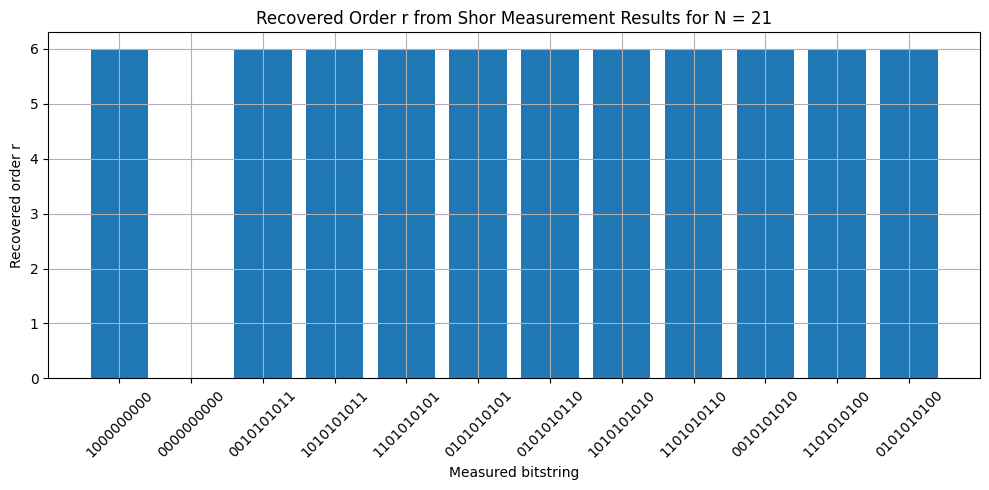

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(df_shor_results["Bitstring"], df_shor_results["Recovered order r"])
ax.set_xlabel("Measured bitstring")
ax.set_ylabel("Recovered order r")
ax.set_title("Recovered Order r from Shor Measurement Results for N = 21")
ax.tick_params(axis="x", rotation=45)
ax.grid(True)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "shor_recovered_order_from_phases.png", bbox_inches="tight", dpi=200)

plt.show()


## 14. Final Summary

The experiment connects RSA factoring to quantum order-finding.


In [30]:
summary_table = pd.DataFrame([
    {
        "Question": "What number was factored?",
        "Answer": "N = 21"
    },
    {
        "Question": "What base was used?",
        "Answer": "a = 2"
    },
    {
        "Question": "What order was recovered?",
        "Answer": "r = 6"
    },
    {
        "Question": "What factors were recovered?",
        "Answer": "3 and 7"
    },
    {
        "Question": "Why does this matter?",
        "Answer": "Factoring n allows RSA private key recovery"
    },
    {
        "Question": "What is the limitation?",
        "Answer": "This is a toy-scale simulation, not a real RSA attack"
    }
])

summary_table


,Question,Answer
0,What number was factored?,N = 21
1,What base was used?,a = 2
2,What order was recovered?,r = 6
3,What factors were recovered?,3 and 7
4,Why does this matter?,Factoring n allows RSA private key recovery
5,What is the limitation?,"This is a toy-scale simulation, not a real RSA..."


## 15. Connection to the Full Project

This notebook is the direct quantum attack part of the project.

The full project flow is:

`RSA → Classical Factoring → Shor's Algorithm → Grover Search → ML-KEM`

The RSA notebook shows that if `n = 21` is factored into `3 × 7`, the private key can be reconstructed.

This Shor notebook shows how quantum order-finding can recover those same factors.

The later ML-KEM notebook responds to this threat by demonstrating a post-quantum key establishment method that does not rely on integer factorization.

## Limitations

This notebook uses a toy-scale implementation.

Important limitations:

1. `N = 21` is very small.
2. The modular multiplication gate is built as a matrix, which is not scalable.
3. The simulator result does not mean real RSA is broken.
4. Real RSA-sized Shor implementations would require many more logical qubits and quantum error correction.
5. The goal is to explain the idea of Shor's algorithm, not to build a production cryptographic attack.
